# Test Image Extraction

This notebook exercises `extract_images.py` against the Maroon PDF corpus in `output/pdfs/`.
It first previews a single page with Newspaper Navigator detections, then runs extraction
across all PDFs and saves cropped image regions under `output/extracted_images/` using the
same year/month directory structure as the source PDFs.

## Setup

Before running these cells, use the image-extraction environment:

```bash
conda env create -f img_extractor.yml
conda activate image-extractor
python -m pip install --no-build-isolation 'git+https://github.com/facebookresearch/detectron2.git'
mkdir -p ~/newspaper_navigator_model
wget -O ~/newspaper_navigator_model/model_final.pth \
  "https://github.com/LibraryOfCongress/newspaper-navigator/releases/download/v1.0.0/model_final.pth"
```

In [8]:
from pathlib import Path
from collections import Counter
import importlib
import json

from IPython.display import display
from PIL import Image
from tqdm.notebook import tqdm

import extract_images
importlib.reload(extract_images)

from extract_images import (
    DEFAULT_METADATA_PATH,
    DEFAULT_MODEL_WEIGHTS,
    EXTRACTED_IMAGES_DIR,
    PDF_ROOT,
    detect_layout,
    draw_detection_preview,
    extract_images_from_pdf,
    filter_layout_blocks,
    find_pdfs,
    load_newspaper_navigator_model,
    render_pdf_page,
    write_metadata,
)

ALL_IMAGE_LABELS = ["Photograph", "Illustration", "Map", "Comics/Cartoon", "Editorial Cartoon"]

In [9]:
pdf_paths = find_pdfs(PDF_ROOT)
len(pdf_paths), pdf_paths[:3]

(3614,
 [PosixPath('/Users/rf50/uchicago/maroon/scrape-maroon-archives/output/pdfs/1902/10/.ipynb_checkpoints/mvol-0004-1902-1022-checkpoint.pdf'),
  PosixPath('/Users/rf50/uchicago/maroon/scrape-maroon-archives/output/pdfs/1902/10/mvol-0004-1902-1001.pdf'),
  PosixPath('/Users/rf50/uchicago/maroon/scrape-maroon-archives/output/pdfs/1902/10/mvol-0004-1902-1002.pdf')])

## Preview One Page

These are the core Newspaper Navigator demo lines: load the model, render a page,
run detections, and filter down to image-like classes.

In [ ]:
1977-0930
1981-0501 # photographs on p1
1983-0923 # photographs on p4

[i for i, _path in enumerate(pdf_paths) if '1983-0923' in str(_path)]

In [61]:
i_test = 3486 #photograph
i_test = 3559 # map on pg.4

In [62]:
model = load_newspaper_navigator_model(weights_path=DEFAULT_MODEL_WEIGHTS)
sample_pdf = pdf_paths[i_test]
page_image = render_pdf_page(sample_pdf, page_number=4, dpi=144)
layout = detect_layout(model, page_image)
image_blocks = filter_layout_blocks(layout, labels_to_keep=ALL_IMAGE_LABELS, min_side=48)

print(sample_pdf)
print(f"Detected {len(image_blocks)} image-like regions on page 1")

/Users/rf50/uchicago/maroon/scrape-maroon-archives/output/pdfs/1983/09/mvol-0004-1983-0923.pdf
Detected 1 image-like regions on page 1


In [63]:
[img.type for img in image_blocks]

['Map']

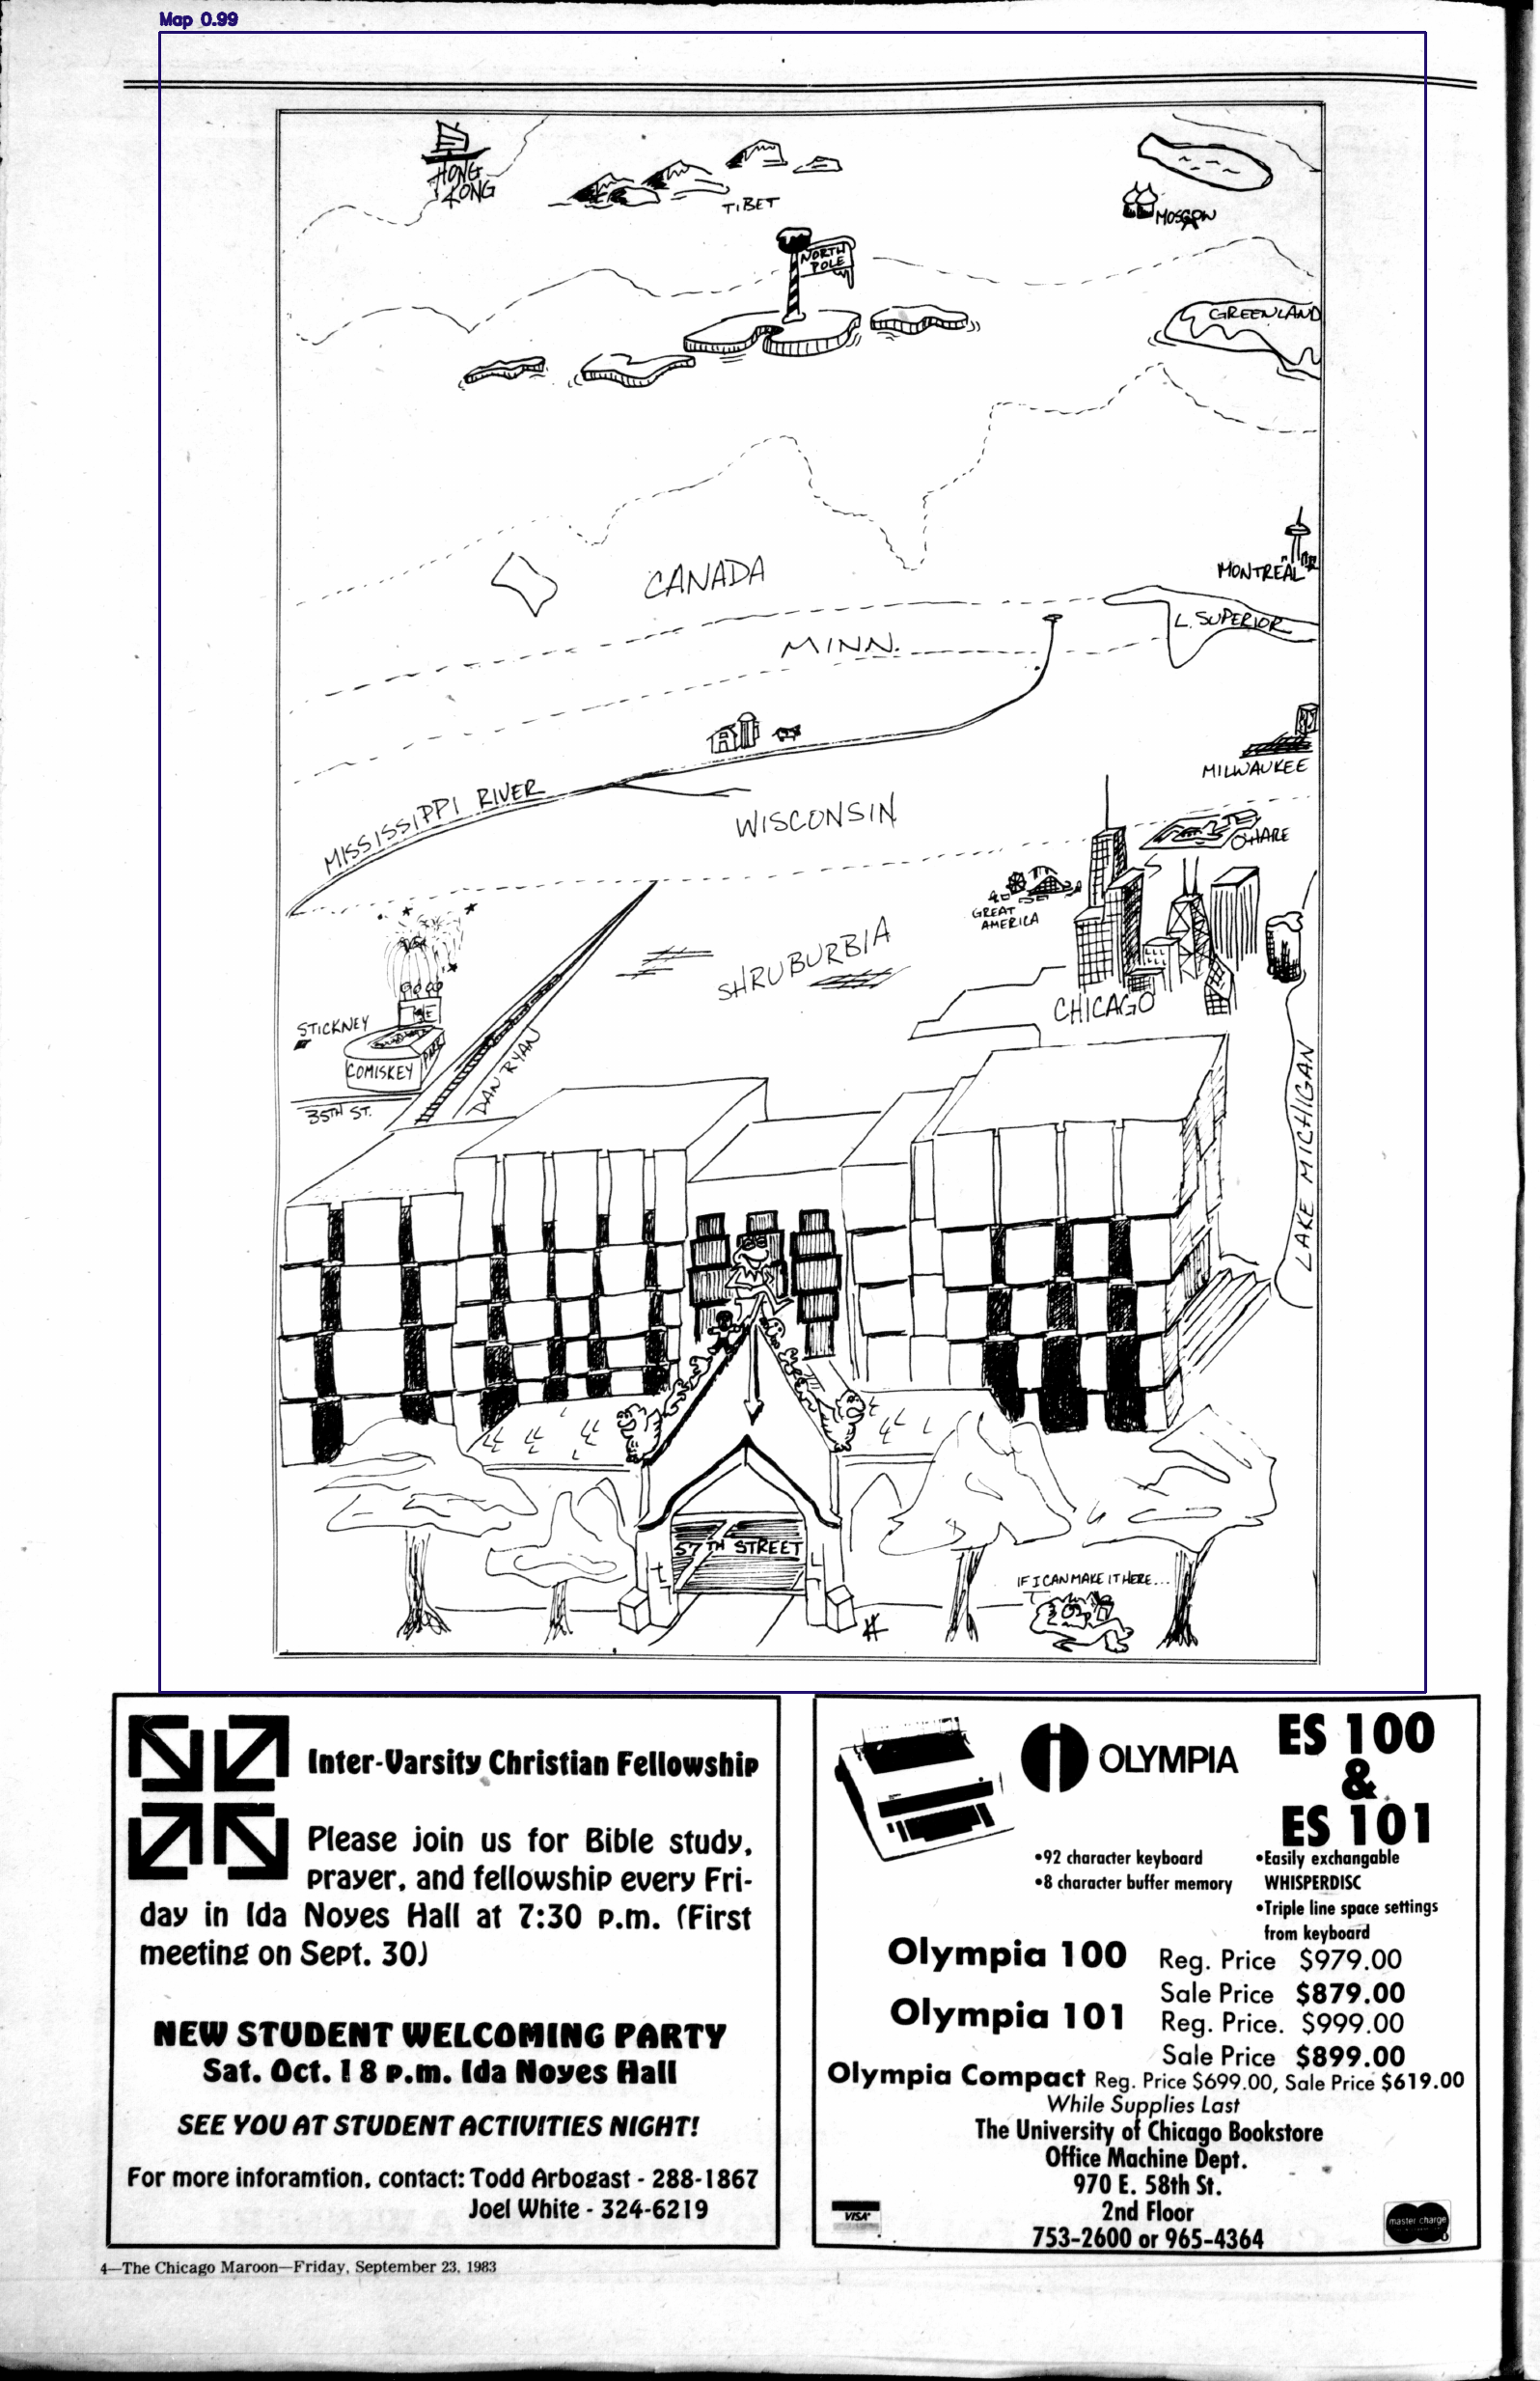

In [64]:
preview_bgr = draw_detection_preview(page_image, image_blocks)
preview_rgb = preview_bgr[:, :, ::-1]
display(Image.fromarray(preview_rgb))

## Run Extraction Across All PDFs

This writes crops under `output/extracted_images/<year>/<month>/<doc_id>/...` and metadata to
`output/metadata/image_regions.jsonl`. That mirrors the PDF directory layout and makes it easy
to trace each crop back to its source issue.

In [ ]:
output_dir = EXTRACTED_IMAGES_DIR
metadata_path = DEFAULT_METADATA_PATH
dpi = 144
page_limit = None  # Set to an integer like 2 for a smaller test run.

all_rows = []
for pdf_path in tqdm(pdf_paths, desc="Extracting image regions"):
    rows = extract_images_from_pdf(
        pdf_path=pdf_path,
        model=model,
        pdf_root=PDF_ROOT,
        output_dir=output_dir,
        labels_to_keep=ALL_IMAGE_LABELS,
        dpi=dpi,
        page_limit=page_limit,
    )
    all_rows.extend(rows)

write_metadata(all_rows, metadata_path)

print(f"Saved {len(all_rows)} crops")
print(f"Crops directory: {output_dir.resolve()}")
print(f"Metadata file: {metadata_path.resolve()}")

Extracting image regions:   0%|          | 0/3614 [00:00<?, ?it/s]

In [ ]:
label_counts = Counter(row["label"] for row in all_rows)
label_counts

In [ ]:
all_rows[:5]

## Preview Saved Crops

In [ ]:
for row in all_rows[:6]:
    print(json.dumps({k: row[k] for k in ["doc_id", "page_number", "label", "score", "crop_path"]}, indent=2))
    display(Image.open(row["crop_path"]))